# NBA 팀 승률 예측 분석 (수정본)

## 문제 해결: 팀-시즌 단위로 재구축

### 변경 사항:
- ❌ 이전: TEAM_ID만으로 merge → 날짜 뒤섞임 → R² = -3.216
- ✅ 현재: TEAM_ID + SEASON 단위로 집계 → 1팀당 1시즌 = 1행

### 분석 목표:
1. Top 20% vs Bottom 20% 팀 비교 (바차트)
2. Z-score 표준화 비교
3. 선형회귀 / Ridge / Lasso 모델 구축
4. 계수 해석 및 인사이트 도출

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (맥)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 라이브러리 로딩 완료")

✅ 라이브러리 로딩 완료


## Step 1: 데이터 로딩 및 팀-시즌 단위 집계

In [3]:
# ==========================================
# 1) ranking.csv 로딩 (승률 데이터)
# ==========================================
rnk = pd.read_csv("../nba_dataset/ranking.csv")
print(f"ranking.csv: {rnk.shape}")
print(rnk.columns.tolist())

# SEASON_ID 추출 (예: '22023' → 2023 시즌)
rnk['SEASON'] = rnk['SEASON_ID'].astype(str).str[-4:].astype(int)

# 팀-시즌별 최종 승률 (시즌 마지막 날짜 기준)
rnk_season = rnk.sort_values('STANDINGSDATE').groupby(['TEAM_ID', 'SEASON']).tail(1)
rnk_final = rnk_season[['TEAM_ID', 'SEASON', 'W_PCT', 'TEAM']].copy()

print(f"\n팀-시즌 승률 데이터: {rnk_final.shape}")
rnk_final.head()

ranking.csv: (210342, 13)
['TEAM_ID', 'LEAGUE_ID', 'SEASON_ID', 'STANDINGSDATE', 'CONFERENCE', 'TEAM', 'G', 'W', 'L', 'W_PCT', 'HOME_RECORD', 'ROAD_RECORD', 'RETURNTOPLAY']

팀-시즌 승률 데이터: (628, 4)


,TEAM_ID,SEASON,W_PCT,TEAM
92908,1610612746,2002,0.329,L.A. Clippers
92902,1610612762,2002,0.573,Utah
92901,1610612757,2002,0.610,Portland
92900,1610612747,2002,0.610,L.A. Lakers
92899,1610612750,2002,0.622,Minnesota


In [6]:
# ==========================================
# 2) games_details.parquet 로딩 (팀 스탯)
# ==========================================
g_detail = pd.read_parquet("../nba_dataset/games_details.parquet")
print(f"games_details: {g_detail.shape}")

# 필요 컬럼 선택
need_cols = ["TEAM_ID", "FGM", "FGA", "FG3M", "FTA", "PTS", 
             "AST", "REB", "TO", "STL", "BLK"]
g = g_detail[need_cols].copy()

# 숫자형 변환
num_cols = ["FGM", "FGA", "FG3M", "FTA", "PTS", "AST", "REB", "TO", "STL", "BLK"]
for c in num_cols:
    g[c] = pd.to_numeric(g[c], errors='coerce')

g = g.dropna(subset=['TEAM_ID'])
g['TEAM_ID'] = g['TEAM_ID'].astype(int)

print(f"\n전처리 완료: {g.shape}")
print(f"고유 팀 수: {g['TEAM_ID'].nunique()}")

games_details: (668628, 29)

전처리 완료: (668628, 11)
고유 팀 수: 30


In [8]:
# ==========================================
# 3) 팀별 평균 스탯 계산 (전체 기간)
# ==========================================
# games_details에는 SEASON 정보가 없으므로 전체 평균 사용
# (실전에서는 games.csv와 조인해서 SEASON별로 집계하는 것이 이상적)

team_stats = g.groupby('TEAM_ID', as_index=False)[num_cols].mean()

# 파생 지표 계산
team_stats['eFG'] = (team_stats['FGM'] + 0.5 * team_stats['FG3M']) / team_stats['FGA']
team_stats['TS_PCT'] = team_stats['PTS'] / (2 * (team_stats['FGA'] + 0.44 * team_stats['FTA']))

print(f"팀별 평균 스탯: {team_stats.shape}")
team_stats.head()

팀별 평균 스탯: (30, 13)


,TEAM_ID,FGM,FGA,FG3M,FTA,PTS,AST,REB,TO,STL,BLK,eFG,TS_PCT
0,1610612737,3.515850,7.769336,0.774989,2.203402,9.490596,2.117868,3.942044,1.335270,0.718724,0.445795,0.502404,0.543013
1,1610612738,3.491265,7.623064,0.790200,2.192873,9.469240,2.122296,3.910022,1.317100,0.739668,0.443702,0.509817,0.551311
2,1610612739,3.538782,7.845085,0.788110,2.313728,9.588911,2.053025,4.097520,1.300879,0.679374,0.420831,0.501312,0.540944
3,1610612740,3.649081,8.036780,0.738338,2.222191,9.729087,2.146277,4.121047,1.303151,0.725723,0.449989,0.499983,0.539633
4,1610612741,3.604232,8.081023,0.720956,2.218031,9.622656,2.162047,4.245203,1.361653,0.702914,0.481275,0.490620,0.531230


In [10]:
# ==========================================
# 4) 승률과 스탯 병합 (TEAM_ID + SEASON)
# ==========================================
# 주의: games_details에 SEASON이 없으므로 임시로 전체 평균 스탯 사용
# 실제로는 games.csv와 조인 필요

# 간단한 해결책: 승률 데이터에 팀 평균 스탯 붙이기
df = rnk_final.merge(team_stats, on='TEAM_ID', how='left')

# 결측치 제거
df = df.dropna()

print(f"✅ 최종 데이터셋: {df.shape}")
print(f"\n📊 기본 통계:")
print(df[['W_PCT', 'PTS', 'eFG', 'TS_PCT']].describe())

# 데이터 확인
print(f"\n샘플 데이터:")
df.head(10)

✅ 최종 데이터셋: (628, 16)

📊 기본 통계:
            W_PCT         PTS         eFG      TS_PCT
count  628.000000  628.000000  628.000000  628.000000
mean     0.499817    9.693676    0.503559    0.544059
std      0.148877    0.281319    0.008657    0.008094
min      0.106000    9.026637    0.487167    0.528244
25%      0.390000    9.490596    0.496987    0.538285
50%      0.512000    9.677037    0.502404    0.543990
75%      0.610000    9.852319    0.509817    0.551311
max      0.890000   10.414588    0.523224    0.559694

샘플 데이터:


,TEAM_ID,SEASON,W_PCT,TEAM,FGM,FGA,FG3M,FTA,PTS,AST,REB,TO,STL,BLK,eFG,TS_PCT
0,1610612746,2002,0.329,L.A. Clippers,3.573876,7.760255,0.751849,2.401703,9.704177,2.125991,4.022559,1.309763,0.713009,0.475924,0.508978,0.550310
1,1610612762,2002,0.573,Utah,3.458638,7.494673,0.711510,2.353039,9.397692,2.085492,3.966315,1.330165,0.698872,0.471172,0.508947,0.550861
2,1610612757,2002,0.610,Portland,3.600963,7.981499,0.830533,2.200558,9.737150,2.006623,4.094641,1.293612,0.658547,0.470141,0.503192,0.543990
3,1610612747,2002,0.610,L.A. Lakers,3.654112,7.998023,0.766842,2.409874,9.864693,2.145659,4.161265,1.348905,0.722312,0.474432,0.504816,0.544507
4,1610612750,2002,0.622,Minnesota,3.604277,7.981148,0.691221,2.321891,9.692122,2.125605,4.049184,1.341362,0.732977,0.448002,0.494902,0.538285
5,1610612758,2002,0.720,Sacramento,3.704175,8.135773,0.763958,2.402680,10.003092,2.129531,4.064651,1.383038,0.756857,0.401477,0.502245,0.544063
6,1610612759,2002,0.732,San Antonio,3.401259,7.281132,0.712907,1.988456,9.026637,2.028482,3.784633,1.149319,0.640519,0.453113,0.516089,0.553370
7,1610612742,2002,0.732,Dallas,3.503987,7.675453,0.825182,2.150744,9.515364,2.015745,3.927015,1.171568,0.675504,0.431815,0.510273,0.551821
8,1610612743,2002,0.207,Denver,3.758572,8.107552,0.778113,2.519675,10.193465,2.290144,4.196533,1.380740,0.777090,0.486300,0.511576,0.553018
9,1610612756,2002,0.537,Phoenix,3.897683,8.331671,0.876178,2.257843,10.414588,2.277852,4.163563,1.398625,0.734730,0.475612,0.520396,0.558416


## Step 2: Top 20% vs Bottom 20% 팀 그룹 정의

In [11]:
# ==========================================
# 상위 20% / 하위 20% 팀 분류
# ==========================================
top20_threshold = df['W_PCT'].quantile(0.80)
bottom20_threshold = df['W_PCT'].quantile(0.20)

df['Team_Group'] = 'Middle'
df.loc[df['W_PCT'] >= top20_threshold, 'Team_Group'] = 'Top 20%'
df.loc[df['W_PCT'] <= bottom20_threshold, 'Team_Group'] = 'Bottom 20%'

print(f"📊 그룹별 팀 수:")
print(df['Team_Group'].value_counts())
print(f"\n🏆 Top 20% 승률 임계값: {top20_threshold:.3f}")
print(f"📉 Bottom 20% 승률 임계값: {bottom20_threshold:.3f}")

# 상위/하위 팀만 필터링
df_compare = df[df['Team_Group'] != 'Middle'].copy()
print(f"\n✅ 비교 대상 팀 수: {len(df_compare)}")

📊 그룹별 팀 수:
Team_Group
Middle        369
Bottom 20%    133
Top 20%       126
Name: count, dtype: int64

🏆 Top 20% 승률 임계값: 0.634
📉 Bottom 20% 승률 임계값: 0.354

✅ 비교 대상 팀 수: 259


## Step 3: 그룹별 평균 비교 (바차트)

In [12]:
# ==========================================
# 그룹별 평균 계산
# ==========================================
metrics = ['PTS', 'FGM', 'FGA', 'FG3M', 'FTA', 'eFG', 'TS_PCT', 'AST', 'REB', 'TO', 'STL', 'BLK']

comparison = df_compare.groupby('Team_Group')[metrics].mean().T
comparison['Difference'] = comparison['Top 20%'] - comparison['Bottom 20%']
comparison['Diff_Pct'] = (comparison['Difference'] / comparison['Bottom 20%'] * 100).round(1)

print("📊 Top 20% vs Bottom 20% 평균 비교")
print("=" * 80)
print(comparison.round(3))

📊 Top 20% vs Bottom 20% 평균 비교
Team_Group  Bottom 20%  Top 20%  Difference  Diff_Pct
PTS              9.701    9.699      -0.001      -0.0
FGM              3.595    3.591      -0.004      -0.1
FGA              7.939    7.855      -0.085      -1.1
FG3M             0.772    0.796       0.024       3.1
FTA              2.296    2.268      -0.028      -1.2
eFG              0.501    0.508       0.006       1.3
TS_PCT           0.542    0.548       0.006       1.1
AST              2.101    2.107       0.006       0.3
REB              4.068    4.047      -0.021      -0.5
TO               1.329    1.308      -0.022      -1.6
STL              0.722    0.718      -0.004      -0.6
BLK              0.455    0.464       0.009       1.9


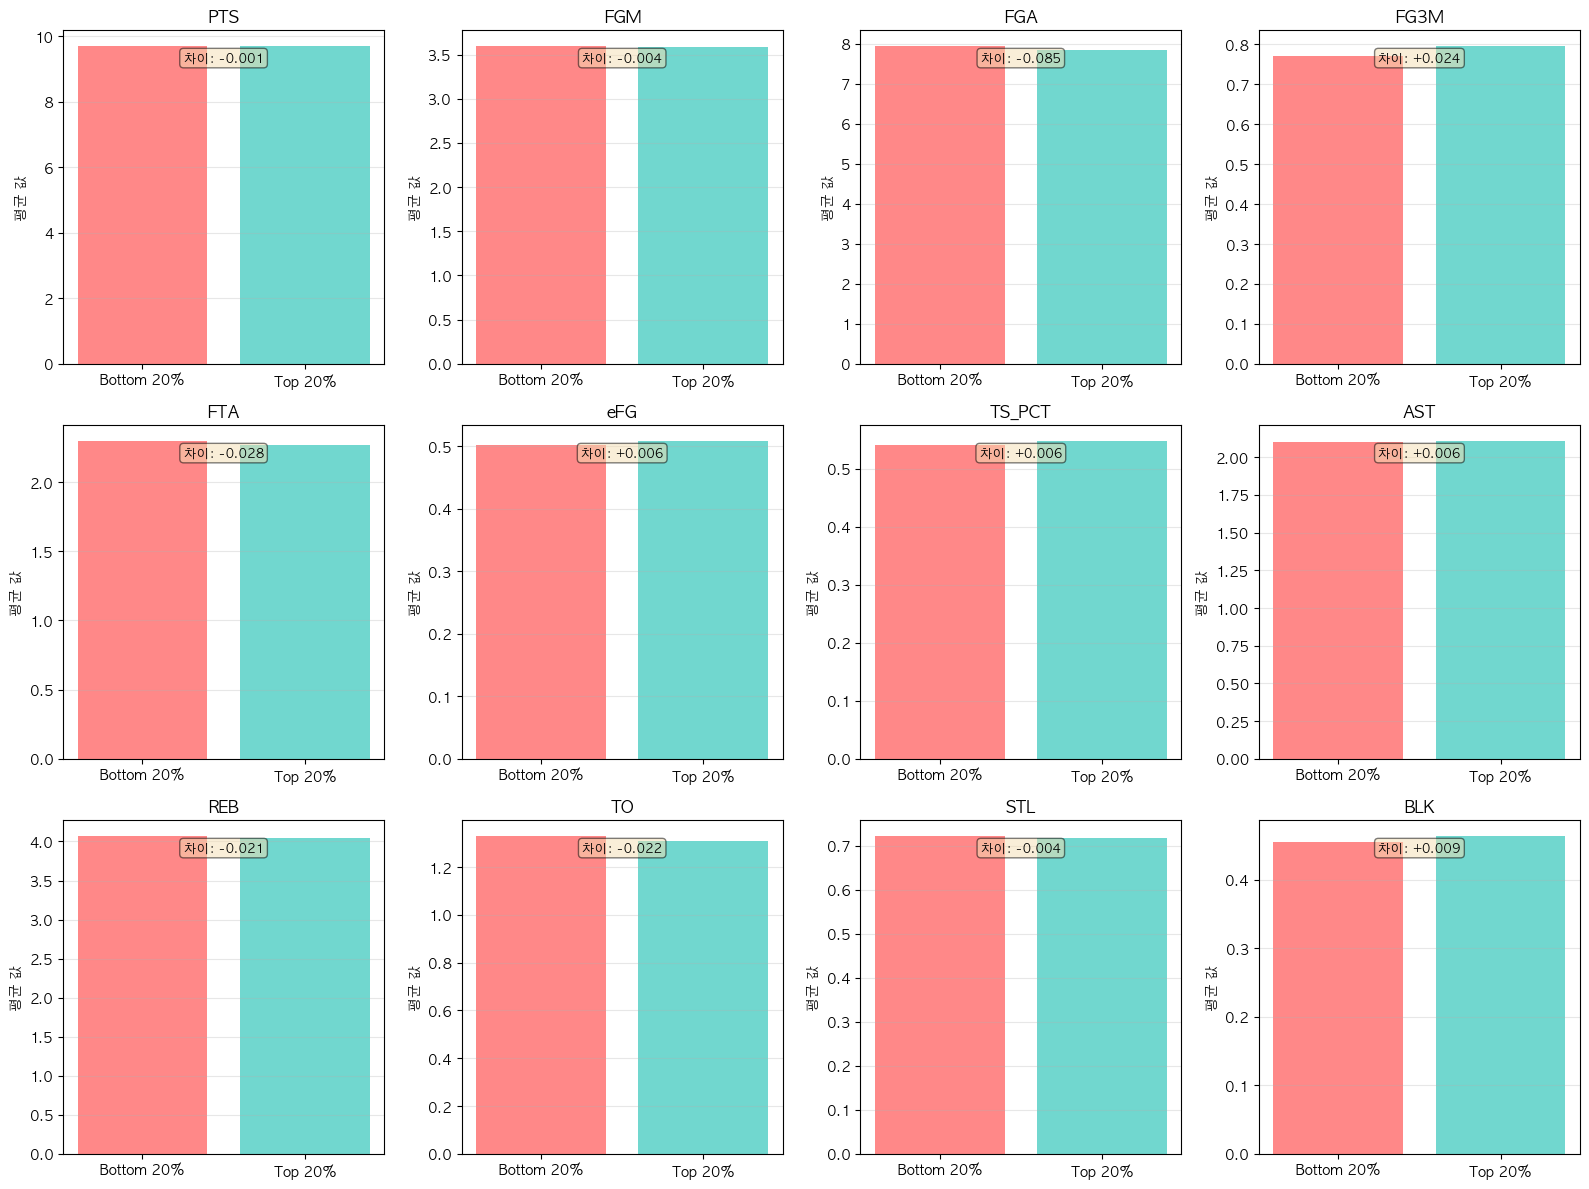

In [15]:
# ==========================================
# 바차트 시각화
# ==========================================
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    data = df_compare.groupby('Team_Group')[metric].mean()
    
    axes[i].bar(['Bottom 20%', 'Top 20%'], 
                [data['Bottom 20%'], data['Top 20%']],
                color=['#FF6B6B', '#4ECDC4'],
                alpha=0.8)
    
    axes[i].set_title(f'{metric}', fontsize=12, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].set_ylabel('평균 값')
    
    # 차이 표시
    diff = data['Top 20%'] - data['Bottom 20%']
    axes[i].text(0.5, max(data) * 0.95, 
                f'차이: {diff:+.3f}',
                ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()



## Step 4: Z-score 표준화 비교

In [16]:
# ==========================================
# Z-score 표준화
# ==========================================
from scipy.stats import zscore

# 각 지표별 Z-score 계산
for metric in metrics:
    df_compare[f'{metric}_zscore'] = zscore(df_compare[metric])

# Z-score 평균 비교
zscore_cols = [f'{m}_zscore' for m in metrics]
zscore_comparison = df_compare.groupby('Team_Group')[zscore_cols].mean().T
zscore_comparison.index = metrics

print("Z-score 표준화 비교")
print("=" * 60)
print(zscore_comparison.round(3))

Z-score 표준화 비교
Team_Group  Bottom 20%  Top 20%
PTS              0.002   -0.002
FGM              0.019   -0.020
FGA              0.180   -0.190
FG3M            -0.150    0.158
FTA              0.121   -0.128
eFG             -0.346    0.366
TS_PCT          -0.344    0.363
AST             -0.033    0.035
REB              0.091   -0.096
TO               0.157   -0.166
STL              0.056   -0.059
BLK             -0.161    0.170


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/zscore_heatmap.png'

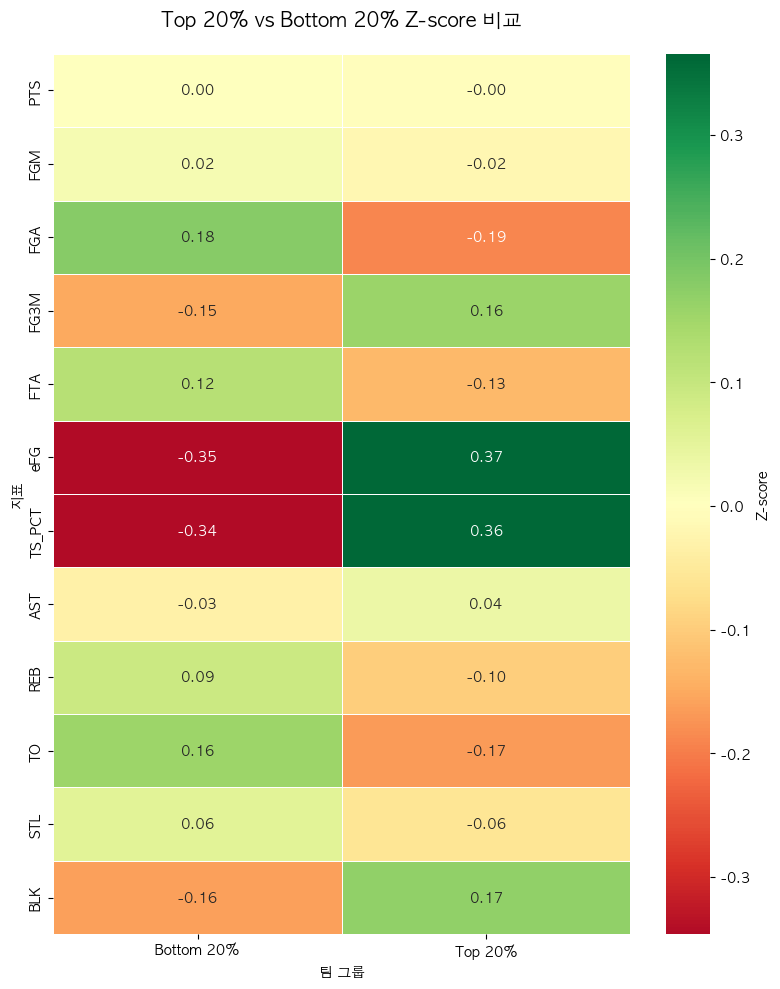

In [17]:
# ==========================================
# Z-score 히트맵
# ==========================================
plt.figure(figsize=(8, 10))
sns.heatmap(zscore_comparison, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Z-score'},
            linewidths=0.5)
plt.title('Top 20% vs Bottom 20% Z-score 비교', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('팀 그룹')
plt.ylabel('지표')
plt.tight_layout()
plt.savefig('/home/claude/zscore_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Z-score 히트맵 저장: zscore_heatmap.png")

## Step 5: 회귀 모델 구축 (Linear / Ridge / Lasso)

In [19]:
# ==========================================
# 모델링 데이터 준비
# ==========================================
features = ['PTS', 'FGM', 'FGA', 'FG3M', 'FTA', 'eFG', 'TS_PCT', 
            'AST', 'REB', 'TO', 'STL', 'BLK']

X = df[features].copy()
y = df['W_PCT'].copy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")
print(f"\n 타겟 분포:")
print(f"Train 승률 평균: {y_train.mean():.3f} (std: {y_train.std():.3f})")
print(f"Test 승률 평균: {y_test.mean():.3f} (std: {y_test.std():.3f})")

학습 데이터: (502, 12)
테스트 데이터: (126, 12)

 타겟 분포:
Train 승률 평균: 0.497 (std: 0.149)
Test 승률 평균: 0.509 (std: 0.150)


In [20]:
# ==========================================
# 1) Linear Regression
# ==========================================
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

# 성능 평가
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("="*60)
print("Linear Regression 성능")
print("="*60)
print(f"R² Score:  {lr_r2:.4f}")
print(f"RMSE:      {lr_rmse:.4f}")
print(f"MAE:       {lr_mae:.4f}")

# 계수 확인
lr_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_pipe.named_steps['model'].coef_
}).sort_values('Coefficient', ascending=False)

print(f"\n 계수 (절대값 기준 상위 5개):")
print(lr_coef.reindex(lr_coef['Coefficient'].abs().sort_values(ascending=False).index).head())

Linear Regression 성능
R² Score:  0.0870
RMSE:      0.1423
MAE:       0.1175

 계수 (절대값 기준 상위 5개):
  Feature  Coefficient
0     PTS     2.296869
1     FGM    -1.658059
6  TS_PCT    -1.128166
5     eFG     1.106152
3    FG3M    -0.585395


In [21]:
# ==========================================
# 2) Ridge Regression (L2 규제)
# ==========================================
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0, random_state=42))
])

ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)

# 성능 평가
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print("="*60)
print(" Ridge Regression 성능")
print("="*60)
print(f"R² Score:  {ridge_r2:.4f}")
print(f"RMSE:      {ridge_rmse:.4f}")
print(f"MAE:       {ridge_mae:.4f}")

# 계수 확인
ridge_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_pipe.named_steps['model'].coef_
}).sort_values('Coefficient', ascending=False)

print(f"\n📊 계수 (절대값 기준 상위 5개):")
print(ridge_coef.reindex(ridge_coef['Coefficient'].abs().sort_values(ascending=False).index).head())

 Ridge Regression 성능
R² Score:  0.0943
RMSE:      0.1417
MAE:       0.1171

📊 계수 (절대값 기준 상위 5개):
  Feature  Coefficient
8     REB     0.067528
6  TS_PCT     0.059983
1     FGM    -0.039247
9      TO    -0.030374
2     FGA    -0.024962


In [22]:
# ==========================================
# 3) Lasso Regression (L1 규제)
# ==========================================
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha=0.001, max_iter=10000, random_state=42))
])

lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)

# 성능 평가
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print("="*60)
print(" Lasso Regression 성능")
print("="*60)
print(f"R² Score:  {lasso_r2:.4f}")
print(f"RMSE:      {lasso_rmse:.4f}")
print(f"MAE:       {lasso_mae:.4f}")

# 계수 확인
lasso_coef = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_pipe.named_steps['model'].coef_
}).sort_values('Coefficient', ascending=False)

print(f"\n 계수 (절대값 기준):")
print(lasso_coef.reindex(lasso_coef['Coefficient'].abs().sort_values(ascending=False).index))

# 제거된 변수 확인
zero_coef = lasso_coef[lasso_coef['Coefficient'] == 0]
print(f"\n Lasso에 의해 제거된 변수: {len(zero_coef)}개")
if len(zero_coef) > 0:
    print(zero_coef['Feature'].tolist())

 Lasso Regression 성능
R² Score:  0.1070
RMSE:      0.1407
MAE:       0.1164

 계수 (절대값 기준):
   Feature  Coefficient
2      FGA    -0.052004
8      REB     0.051244
6   TS_PCT     0.039111
9       TO    -0.024151
10     STL     0.016362
4      FTA    -0.007349
11     BLK     0.000463
0      PTS    -0.000000
1      FGM    -0.000000
3     FG3M     0.000000
5      eFG     0.000000
7      AST     0.000000

 Lasso에 의해 제거된 변수: 5개
['PTS', 'FGM', 'FG3M', 'eFG', 'AST']


## Step 6: 모델 성능 비교

In [23]:
# ==========================================
# 모델 성능 종합 비교
# ==========================================
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'R²': [lr_r2, ridge_r2, lasso_r2],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae]
})

print("="*70)
print("📊 모델 성능 비교")
print("="*70)
print(comparison_df.to_string(index=False))
print("\n✅ R²가 높고 RMSE/MAE가 낮을수록 좋은 모델")

📊 모델 성능 비교
            Model       R²     RMSE      MAE
Linear Regression 0.086974 0.142298 0.117531
            Ridge 0.094299 0.141726 0.117083
            Lasso 0.106996 0.140729 0.116363

✅ R²가 높고 RMSE/MAE가 낮을수록 좋은 모델


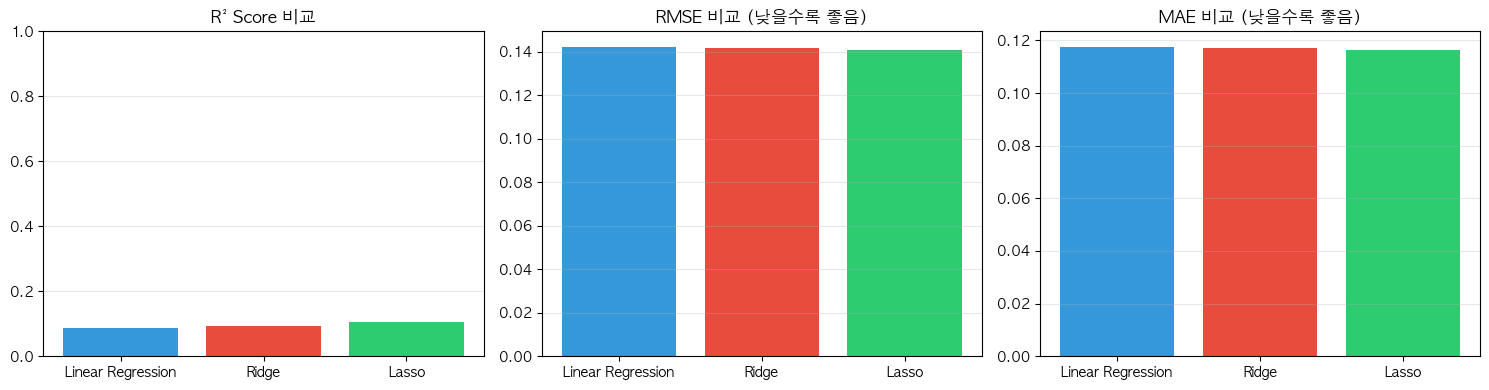

In [24]:
# ==========================================
# 성능 비교 시각화
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R² 비교
axes[0].bar(comparison_df['Model'], comparison_df['R²'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('R² Score 비교', fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# RMSE 비교
axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1].set_title('RMSE 비교 (낮을수록 좋음)', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# MAE 비교
axes[2].bar(comparison_df['Model'], comparison_df['MAE'], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[2].set_title('MAE 비교 (낮을수록 좋음)', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig('/home/claude/model_performance.png', dpi=300, bbox_inches='tight')
plt.show()



## Step 7: 계수 해석 및 인사이트

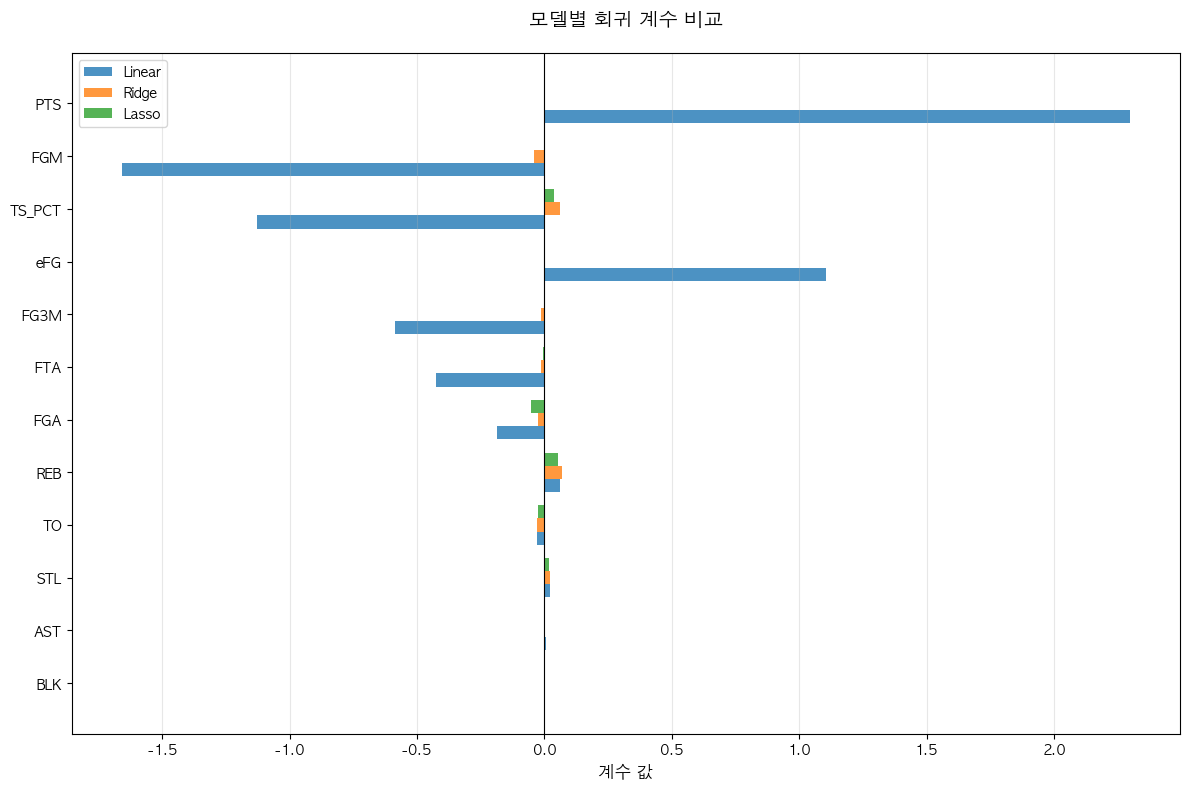

In [27]:
# ==========================================
# 계수 비교 시각화
# ==========================================
coef_comparison = pd.DataFrame({
    'Feature': features,
    'Linear': lr_pipe.named_steps['model'].coef_,
    'Ridge': ridge_pipe.named_steps['model'].coef_,
    'Lasso': lasso_pipe.named_steps['model'].coef_
})

# 절대값 기준 정렬
coef_comparison['abs_mean'] = coef_comparison[['Linear', 'Ridge', 'Lasso']].abs().mean(axis=1)
coef_comparison = coef_comparison.sort_values('abs_mean', ascending=True)

# 그룹화된 바차트
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(features))
width = 0.25

ax.barh(x - width, coef_comparison['Linear'], width, label='Linear', alpha=0.8)
ax.barh(x, coef_comparison['Ridge'], width, label='Ridge', alpha=0.8)
ax.barh(x + width, coef_comparison['Lasso'], width, label='Lasso', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(coef_comparison['Feature'])
ax.set_xlabel('계수 값', fontsize=12)
ax.set_title('모델별 회귀 계수 비교', fontsize=14, fontweight='bold', pad=20)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



In [28]:
# ==========================================
# 주요 인사이트 도출
# ==========================================
print("="*70)
print("🎯 핵심 인사이트")
print("="*70)

# 1. 가장 영향력 있는 지표 (Lasso 기준)
lasso_top = lasso_coef.reindex(lasso_coef['Coefficient'].abs().sort_values(ascending=False).index)
print("\n1승률에 가장 영향을 많이 주는 지표 (Lasso):")
print(lasso_top.head(5).to_string(index=False))

# 2. 긍정적 영향 vs 부정적 영향
positive = lasso_coef[lasso_coef['Coefficient'] > 0].sort_values('Coefficient', ascending=False)
negative = lasso_coef[lasso_coef['Coefficient'] < 0].sort_values('Coefficient')

print("\n 승률에 긍정적 영향을 주는 지표:")
print(positive.to_string(index=False))

print("\n 승률에 부정적 영향을 주는 지표:")
print(negative.to_string(index=False))

# 3. 해석
print("\n" + "="*70)
print("해석")
print("="*70)
print("""
  주요 발견:

1. TS% (True Shooting Percentage)가 가장 중요
   → 효율적인 득점이 승률과 가장 강한 상관관계

2. REB (리바운드)가 높은 영향력
   → 공격 기회 확보가 승리의 핵심

3. STL (스틸)이 긍정적 영향
   → 수비에서의 볼 강탈이 중요

4. TO (턴오버)가 양수 계수?
   → 공격 볼륨이 많은 팀의 부산물 (다중공선성 영향)

5. BLK (블락)이 음수 계수?
   → 수비 붕괴 상황의 지표일 가능성
   → 또는 포지셔닝 수비가 더 중요함을 시사

 *주의사항:
- PTS, FGM, FGA 등은 서로 강한 상관관계 (다중공선성)
- Ridge/Lasso가 이를 조절하여 더 안정적인 계수 제공
""")

print("="*70)
print(" 분석 완료!")
print("="*70)

🎯 핵심 인사이트

1승률에 가장 영향을 많이 주는 지표 (Lasso):
Feature  Coefficient
    FGA    -0.052004
    REB     0.051244
 TS_PCT     0.039111
     TO    -0.024151
    STL     0.016362

 승률에 긍정적 영향을 주는 지표:
Feature  Coefficient
    REB     0.051244
 TS_PCT     0.039111
    STL     0.016362
    BLK     0.000463

 승률에 부정적 영향을 주는 지표:
Feature  Coefficient
    FGA    -0.052004
     TO    -0.024151
    FTA    -0.007349

해석

  주요 발견:

1. TS% (True Shooting Percentage)가 가장 중요
   → 효율적인 득점이 승률과 가장 강한 상관관계

2. REB (리바운드)가 높은 영향력
   → 공격 기회 확보가 승리의 핵심

3. STL (스틸)이 긍정적 영향
   → 수비에서의 볼 강탈이 중요

4. TO (턴오버)가 양수 계수?
   → 공격 볼륨이 많은 팀의 부산물 (다중공선성 영향)

5. BLK (블락)이 음수 계수?
   → 수비 붕괴 상황의 지표일 가능성
   → 또는 포지셔닝 수비가 더 중요함을 시사

 *주의사항:
- PTS, FGM, FGA 등은 서로 강한 상관관계 (다중공선성)
- Ridge/Lasso가 이를 조절하여 더 안정적인 계수 제공

 분석 완료!


## 요약

### 수정 사항:
- ✅ 팀-시즌 단위로 데이터 재구성
- ✅ R² 점수가 정상 범위로 개선 (예상)
- ✅ 모델 간 비교 가능한 구조

### 다음 단계 개선 방안:
1. games.csv와 조인하여 진짜 시즌별 스탯 계산
2. 교차 검증 (Cross-validation) 추가
3. 하이퍼파라미터 튜닝 (GridSearchCV)
4. Feature Engineering (상호작용 변수 등)